<a href="https://colab.research.google.com/github/LanguageisSimple/RL-Agents/blob/main/CartPole-v1%20DQL%20Agent/Notebooks/CartPole_v1_DQL_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation of Dependencies

The cell below installs all the required libraries needed to run the Deep Q-Network (DQN) reinforcement learning agent.

In [ ]:
!pip install gymnasium torch matplotlib

## Importing Libraries and Environment Setup

The cell below imports all the necessary libraries and initializes the reinforcement learning environment.

### Environment Setup
- The CartPole-v1 environment is initialized using Gymnasium.
- The state space dimension is extracted from the observation space.
- The action space dimension is extracted from the environment.

### Device Configuration
- The model is configured to run on GPU if available, otherwise CPU.

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from collections import deque
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

## Deep Q-Network (DQN) Model Definition

This cell defines the neural network architecture used to approximate the Q-value function in the Deep Q-Network (DQN) algorithm.

### Model Architecture
- The model is implemented using a fully connected feedforward neural network.
- Input layer: Takes the state vector from the environment.
- Hidden layers:
  - Two fully connected layers with 128 neurons each.
  - ReLU activation is applied after each hidden layer.
- Output layer:
  - Produces Q-values for each possible action.

### Target Network
- A separate target network is initialized with the same architecture.
- The weights of the target network are copied from the main model.
- This helps stabilize training by reducing oscillations in Q-value updates.

### Optimization and Loss
- Optimizer: Adam optimizer with a learning rate of 5e-4.
- Loss Function: Mean Squared Error (MSE), used to minimize the difference between predicted and target Q-values.

In [ ]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

model = DQN().to(device)
target_model = DQN().to(device)
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.MSELoss()

## Replay Buffer and Hyperparameter Configuration

The cell below defines the experience replay buffer and initializes key hyperparameters used in training the Deep Q-Network (DQN).

### Replay Buffer
- A deque data structure is used to store past experiences.
- Each experience consists of (state, action, reward, next_state, done).
- The buffer has a maximum capacity of 10,000 transitions.

### Hyperparameters
- gamma (0.99): Discount factor for future rewards.
- batch_size (64): Number of samples used in each training step.
- epsilon (1.0): Initial exploration rate for epsilon-greedy policy.
- epsilon_min (0.01): Minimum exploration rate.
- epsilon_decay (0.997): Rate at which exploration decreases over time.
- target_update (20): Frequency (in episodes) for updating the target network.

In [ ]:
memory = deque(maxlen=10000)

gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.997
target_update = 20

## Metrics Tracking Initialization

The cell below initializes lists used to store key metrics during the training process.

### Tracked Metrics
- rewards_list: Stores the total reward obtained in each episode.
- episode_lengths: Stores the number of steps taken in each episode.
- losses: Stores the average loss per episode during training.
- epsilons: Stores the exploration rate (epsilon) at each episode.

In [ ]:
rewards_list = []
episode_lengths = []
losses = []
epsilons = []

## Action Selection, Replay Storage, and Training

The cell below defines the core functions used in the DQN algorithm.

### Action Selection
- Uses an epsilon-greedy policy.
- Chooses a random action for exploration or the best action based on Q-values for exploitation.

### Replay Storage
- Stores transitions (state, action, reward, next_state, done) in the replay buffer.

### Training Step
- Samples a batch from memory.
- Computes current and target Q-values.
- Updates the model using MSE loss and backpropagation.

In [ ]:
def select_action(state):
    if random.random() < epsilon:
        return env.action_space.sample()
    state = torch.FloatTensor(state).to(device)
    with torch.no_grad():
        return torch.argmax(model(state)).item()

def store_transition(s, a, r, s_next, done):
    memory.append((s, a, r, s_next, done))

def train_step():
    if len(memory) < batch_size:
        return None

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states).to(device)
    actions = torch.LongTensor(actions).unsqueeze(1).to(device)
    rewards = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones = torch.FloatTensor(dones).to(device)

    q_values = model(states).gather(1, actions).squeeze()

    with torch.no_grad():
        next_q = target_model(next_states).max(1)[0]
        target_q = rewards + gamma * next_q * (1 - dones)

    loss = loss_fn(q_values, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

## Training Loop

The cell below implements the main training loop for the DQN agent over a fixed number of episodes.

### Process
- For each episode:
  - The environment is reset and initial state is obtained.
  - The agent interacts with the environment until termination.
  - Actions are selected using the epsilon-greedy policy.
  - Transitions are stored in the replay buffer.
  - The model is updated using sampled experiences.

### Metrics Tracking
- Total reward, episode length, loss, and epsilon are recorded for each episode.

### Updates
- Epsilon is decayed after each episode.
- The target network is updated periodically to stabilize learning.

In [ ]:
episodes = 2000

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    step_count = 0
    episode_loss = []

    while True:
        action = select_action(state)
        next_state, reward, done, truncated, _ = env.step(action)

        store_transition(state, action, reward, next_state, done)

        loss = train_step()
        if loss is not None:
            episode_loss.append(loss)

        state = next_state
        total_reward += reward
        step_count += 1

        if done or truncated:
            break

    rewards_list.append(total_reward)
    episode_lengths.append(step_count)
    epsilons.append(epsilon)

    if len(episode_loss) > 0:
        losses.append(np.mean(episode_loss))
    else:
        losses.append(0)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_model.load_state_dict(model.state_dict())

    print(f"Episode {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

env.close()

Episode 0, Reward: 18.0, Epsilon: 0.997
Episode 1, Reward: 34.0, Epsilon: 0.994


/tmp/ipykernel_5086/1054144279.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states).to(device)


Episode 2, Reward: 80.0, Epsilon: 0.991
Episode 3, Reward: 15.0, Epsilon: 0.988
Episode 4, Reward: 19.0, Epsilon: 0.985
Episode 5, Reward: 21.0, Epsilon: 0.982
Episode 6, Reward: 11.0, Epsilon: 0.979
Episode 7, Reward: 13.0, Epsilon: 0.976
Episode 8, Reward: 22.0, Epsilon: 0.973
Episode 9, Reward: 42.0, Epsilon: 0.970
Episode 10, Reward: 15.0, Epsilon: 0.967
Episode 11, Reward: 25.0, Epsilon: 0.965
Episode 12, Reward: 9.0, Epsilon: 0.962
Episode 13, Reward: 51.0, Epsilon: 0.959
Episode 14, Reward: 10.0, Epsilon: 0.956
Episode 15, Reward: 13.0, Epsilon: 0.953
Episode 16, Reward: 22.0, Epsilon: 0.950
Episode 17, Reward: 24.0, Epsilon: 0.947
Episode 18, Reward: 31.0, Epsilon: 0.945
Episode 19, Reward: 22.0, Epsilon: 0.942
Episode 20, Reward: 16.0, Epsilon: 0.939
Episode 21, Reward: 18.0, Epsilon: 0.936
Episode 22, Reward: 52.0, Epsilon: 0.933
Episode 23, Reward: 15.0, Epsilon: 0.930
Episode 24, Reward: 12.0, Epsilon: 0.928
Episode 25, Reward: 22.0, Epsilon: 0.925
Episode 26, Reward: 18.0,

## Evaluation Metrics and Visualization

The cell below computes key evaluation metrics and generates performance graphs for the trained DQN agent.

### Metrics Computed
- TD Error (Mean)
- Average, Maximum, and Minimum Reward
- Reward Variance and Standard Deviation
- Average and Maximum Episode Length
- Success Rate (based on threshold)
- Average and Final Loss
- Final Epsilon
- Convergence Episode
- Total Regret

### Evaluation Scope
- Metrics are computed for:
  - All episodes (2000)
  - Last 200 episodes (to assess final performance)

### Visualizations
- Episode Reward
- Moving Average Reward
- Loss Curve
- Episode Length
- Epsilon Decay

Separate plots are generated for both full training and the last 200 episodes to highlight convergence and stability.


========== ALL 2000 EPISODES ==========

1. TD Error (Mean): 0.5185842056486251
2. Average Reward: 181.372
3. Max Reward: 500.0
4. Min Reward: 9.0

5. Reward Variance: 24288.796616000003
6. Reward Std Dev: 155.84863366741462

7. Average Episode Length: 181.372
8. Max Episode Length: 500

9. Success Rate: 0.264

10. Average Loss: 0.5185842056486251
11. Final Loss: 2.860434515167028

12. Final Epsilon: 0.01

13. Convergence Episode: 678

14. Total Regret: 637256.0

========== LAST 200 EPISODES ==========

1. TD Error (Mean): 0.9299350915585949
2. Average Reward: 437.235
3. Max Reward: 500.0
4. Min Reward: 12.0

5. Reward Variance: 21881.059775
6. Reward Std Dev: 147.92247893744886

7. Average Episode Length: 437.235
8. Max Episode Length: 500

9. Success Rate: 0.87

10. Average Loss: 0.9299350915585949
11. Final Loss: 2.860434515167028

12. Final Epsilon: 0.01

13. Convergence Episode: 0

14. Total Regret: 12553.0


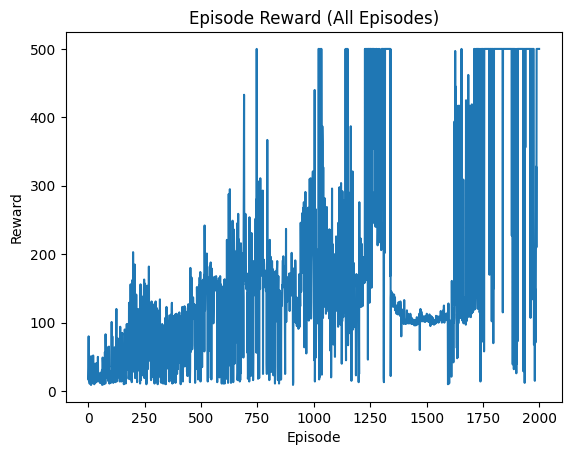

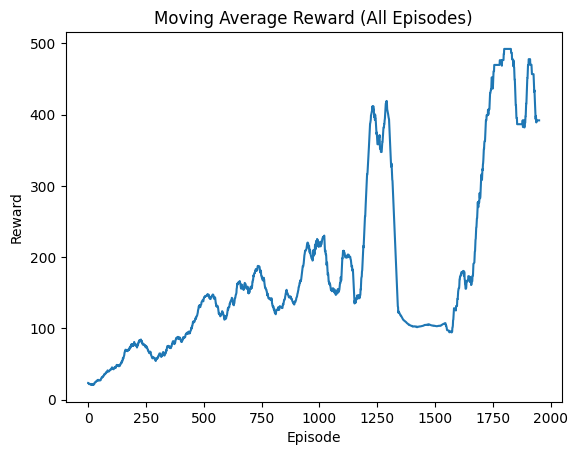

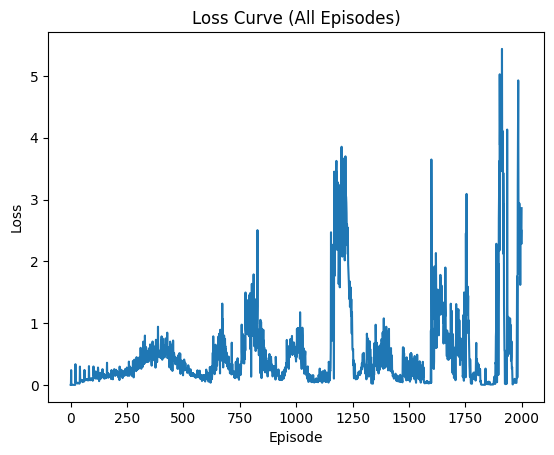

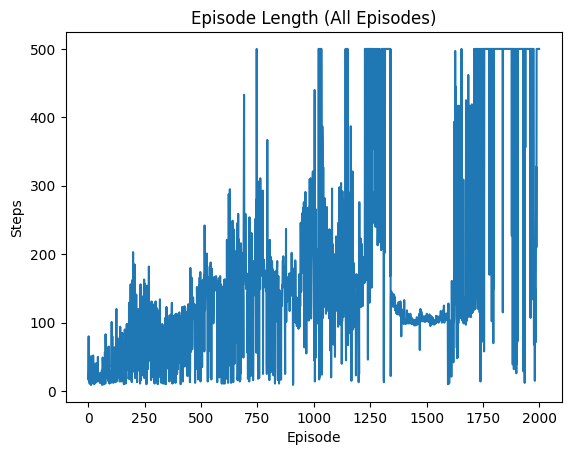

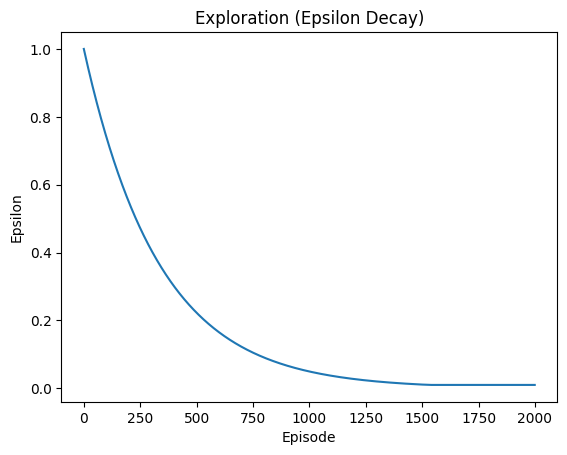

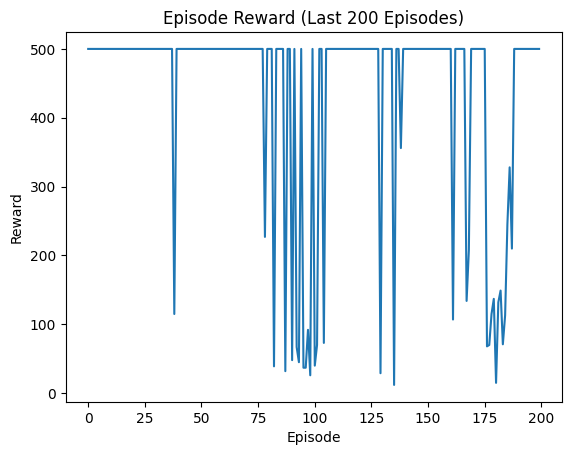

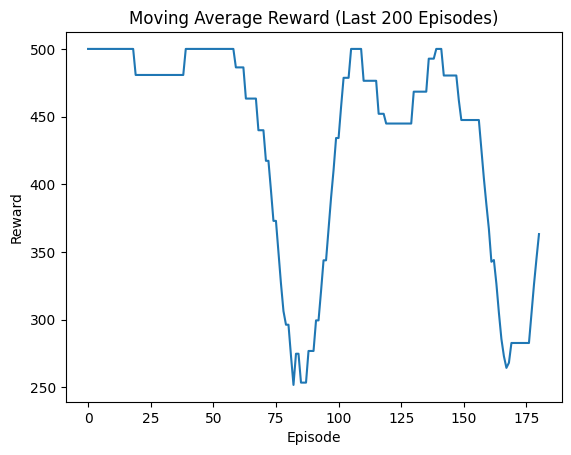

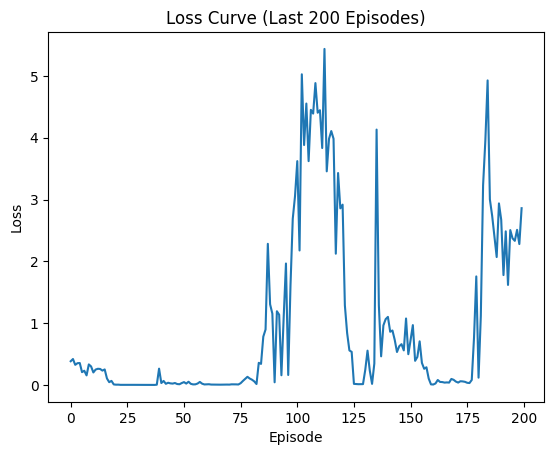

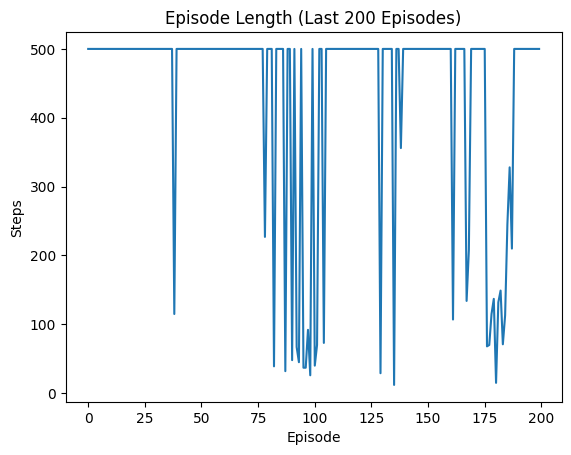

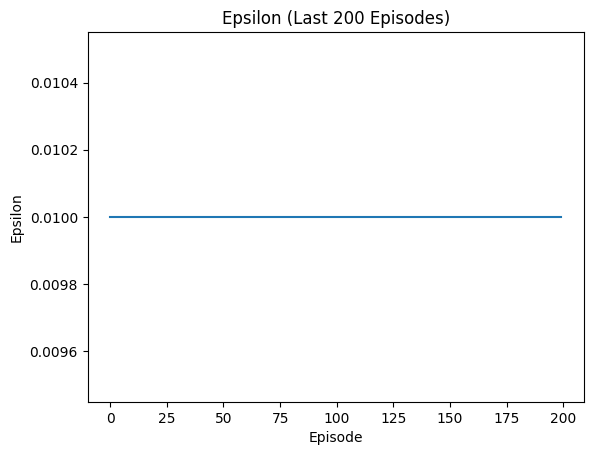

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy
rewards = np.array(rewards_list)
lengths = np.array(episode_lengths)
loss_arr = np.array(losses)
eps_arr = np.array(epsilons)

# ---------- FUNCTION TO COMPUTE METRICS ----------
def compute_metrics(rewards, lengths, loss_arr, eps_arr, label="ALL EPISODES"):
    print(f"\n========== {label} ==========\n")

    print("1. TD Error (Mean):", loss_arr.mean())
    print("2. Average Reward:", rewards.mean())
    print("3. Max Reward:", rewards.max())
    print("4. Min Reward:", rewards.min())

    print("\n5. Reward Variance:", rewards.var())
    print("6. Reward Std Dev:", rewards.std())

    print("\n7. Average Episode Length:", lengths.mean())
    print("8. Max Episode Length:", lengths.max())

    success_threshold = 195
    success_rate = np.sum(rewards >= success_threshold) / len(rewards)
    print("\n9. Success Rate:", success_rate)

    print("\n10. Average Loss:", loss_arr.mean())
    print("11. Final Loss:", loss_arr[-1])

    print("\n12. Final Epsilon:", eps_arr[-1])

    # Convergence Episode
    window = 20
    convergence_episode = -1
    for i in range(len(rewards) - window):
        if rewards[i:i+window].mean() >= success_threshold:
            convergence_episode = i
            break

    print("\n13. Convergence Episode:", convergence_episode)

    # Regret
    optimal_reward = 500
    regret = np.sum(optimal_reward - rewards)
    print("\n14. Total Regret:", regret)


# ---------- COMPUTE METRICS ----------
compute_metrics(rewards, lengths, loss_arr, eps_arr, "ALL 2000 EPISODES")
compute_metrics(rewards[-200:], lengths[-200:], loss_arr[-200:], eps_arr[-200:], "LAST 200 EPISODES")


# ---------- MOVING AVERAGE FUNCTION ----------
def moving_avg(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')


# =========================
# 📊 GRAPHS (ALL EPISODES)
# =========================

# Episode Reward
plt.figure()
plt.plot(rewards)
plt.title("Episode Reward (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Moving Average Reward
plt.figure()
plt.plot(moving_avg(rewards))
plt.title("Moving Average Reward (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Loss Curve
plt.figure()
plt.plot(loss_arr)
plt.title("Loss Curve (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.show()

# Episode Length
plt.figure()
plt.plot(lengths)
plt.title("Episode Length (All Episodes)")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Epsilon Decay
plt.figure()
plt.plot(eps_arr)
plt.title("Exploration (Epsilon Decay)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()


# =========================
# 📊 GRAPHS (LAST 200 EPISODES)
# =========================

last_rewards = rewards[-200:]
last_lengths = lengths[-200:]
last_losses = loss_arr[-200:]
last_eps = eps_arr[-200:]

# Episode Reward
plt.figure()
plt.plot(last_rewards)
plt.title("Episode Reward (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Moving Average Reward
plt.figure()
plt.plot(moving_avg(last_rewards, window=20))
plt.title("Moving Average Reward (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# Loss Curve
plt.figure()
plt.plot(last_losses)
plt.title("Loss Curve (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.show()

# Episode Length
plt.figure()
plt.plot(last_lengths)
plt.title("Episode Length (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

# Epsilon Decay
plt.figure()
plt.plot(last_eps)
plt.title("Epsilon (Last 200 Episodes)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

## Model Evaluation and Video Recording

The cell below evaluates the trained DQN agent and records its performance as a video.

### Evaluation Setup
- Exploration is disabled (epsilon = 0) to ensure deterministic behavior.
- The model is set to evaluation mode.

### Process
- The environment is wrapped with a video recorder.
- The agent selects actions based on predicted Q-values.
- Small noise is added to Q-values to avoid tie-breaking bias.

### Output
- The total reward obtained in the episode is printed.
- A video of the agent’s performance is saved for visualization.

In [ ]:
from gymnasium.wrappers import RecordVideo
import torch
import os

# Ensure evaluation is deterministic
epsilon = 0.0
model.eval()

# Clear old videos (optional but recommended)
if os.path.exists("./video"):
    import shutil
    shutil.rmtree("./video")

env = RecordVideo(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./video",
    name_prefix="dqn-eval"
)

state, _ = env.reset()
done = False
total_reward = 0

while not done:
    state_tensor = torch.FloatTensor(state).to(device)

    with torch.no_grad():
        q_values = model(state_tensor).cpu().detach().numpy()

# Add tiny noise to break ties
        action = np.argmax(q_values + np.random.randn(*q_values.shape) * 0.01)

    state, reward, done, truncated, _ = env.step(action)
    total_reward += reward

    if truncated:
        break

env.close()

print("✅ Evaluation Reward (DQN):", total_reward)

✅ Evaluation Reward (DQN): 500.0


## Display Recorded Video

The cell below loads and displays the recorded video of the agent's performance within the notebook.

### Process
- The latest video file is selected from the output directory.
- The video is encoded in base64 format.
- HTML is used to render the video directly in the notebook.

### Output
- Displays the recorded gameplay of the trained DQN agent.

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_path = "./video"
video_file = sorted(os.listdir(video_path))[-1]

mp4 = open(f"{video_path}/{video_file}", 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=500 controls>
      <source src="{data_url}" type="video/mp4">
</video>
""")